In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio      # βιβιοθήκη για να "παίζουμε" ήχους (μεταξύ άλλων)
from scipy import signal
from scipy.io import wavfile           # βιβλιοθήκη για να "διαβάζουμε" .wav files (μεταξύ άλλων)

## Άσκηση - Ασφαλής Επικοινωνία

Για την ασφαλή επικοινωνία δεδομένων μεταξύ δυο σταθμών, χρησιμοποιούμε ένα πρότυπο σήμα μήκος $50$ δειγμάτων, για να το προσθέσουμε ως θόρυβο σε τυχαίες χρονικές στιγμές στα σήματα που θέλουμε να στείλουμε. Το σήμα-πρότυπο βρίσκεται στο αρχείο ```Pat.wav```, και το έχουν τόσο ο πομπός όσο και ο δέκτης. Το σήμα που εμείς λάβαμε σε κάποια χρονική στιγμή στο δέκτη είναι το σήμα ```noisySpeech.wav```. Ας τα φορτώσουμε και ας τα ακούσουμε:


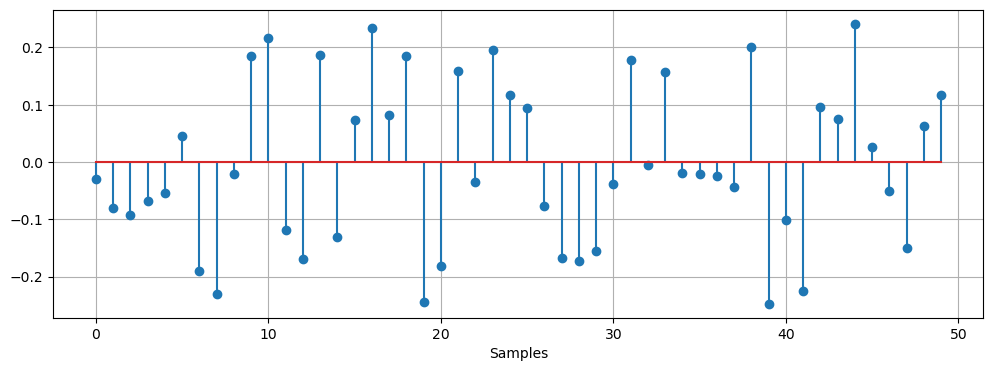

In [2]:
fs, pattern = wavfile.read('./files/Pat.wav')     # διαβάζουμε το συνοδευτικό wav αρχείο - σήμα προτύπου θορύβου
pattern = pattern / (2**15)                       # κανονικοποιούμε στο [-1,1]

fig = plt.figure(figsize=(12,4))  
plt.stem(pattern)
plt.xlabel('Samples')
plt.grid()
plt.show()

In [3]:
Audio(pattern, rate=fs)             # ακούμε! :)

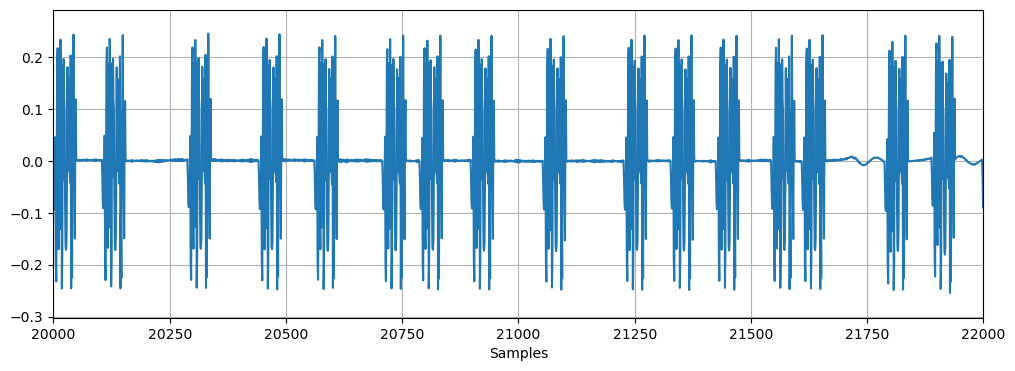

In [4]:
fs, noisy = wavfile.read('./files/noisySpeech.wav')     # διαβάζουμε το συνοδευτικό wav αρχείο
noisy = noisy / (2**15)                                 # κανονικοποιούμε στο [-1,1]

fig = plt.figure(figsize=(12,4))  
plt.plot(noisy); 
plt.xlabel('Samples')
plt.grid()
plt.xlim(20000, 22000)                                  # Ζουμ σε μια περιοχή
plt.show()

In [5]:
Audio(noisy, rate=fs)             # ακούμε! :) (ΧΑΜΗΛΑ ΤΗΝ ΕΝΤΑΣΗ)


Η εντολή $\texttt{plot}$ είναι βολικότερη εδώ για την απεικόνιση, αλλά στην πραγματικότητα τα σήματά μας είναι διακριτού χρόνου (μπορείτε να το δείτε με την εντολή $\texttt{stem}$, όπως την γνωρίζετε).

Θα θέλαμε να ανακτήσουμε το καθαρό σήμα. Για το σκοπό αυτό, μπορούμε να χρησιμοποιήσουμε την πράξη της **ετεροσυσχέτισης**, η οποία ορίζεται ως

$$r_{xy}[l] = \sum_{n=-\infty}^{+\infty} x[n]y[n+l]$$

Η συνάρτηση ```cross_corr = signal.correlate(...)``` της βιβλιοθήκης ```SciPy``` θα σας βοηθήσει να συσχετίσετε τα σήματα. Δείτε προσεκτικά (!) το *documentation* της, καθώς η υλοποίηση διαφέρει λίγο από τον παραπάνω ορισμό, και όπως ίσως θυμάστε και από το συνεχή χρόνο, η ετεροσυσχέτιση είναι διαφορετική όταν συσχετίσουμε το $x[n]$ με το $y[n]$ απ' όταν συσχετίσουμε το $y[n]$ με το $x[n]$. Στις χρονικές τιμές των *lags* όπου η τιμή της ετεροσυσχέτισης είναι μεγάλη, σημαίνει ότι εκεί έχει βρεθεί μεγάλη ομοιότητα του ενός σήματος με το άλλο. Χρησιμοποιήστε τη συνάρτηση ```signal.correlation_lags``` για να βρείτε τις χρονικές στιγμές της ετεροσυσχέτισης.

Προς βοήθειά σας, πληροφορείστε ότι το πρότυπο σήμα έχει προστεθεί σε $650$ (!!) τυχαίες θέσεις στο σήμα ```noisySpeech.wav```. Αν βρείτε αυτές τις θέσεις, μπορείτε απλά να το αφαιρέσετε με μια απλή πράξη αφαίρεσης του σήματος προτύπου από το θορυβώδες σήμα. Επίσης, το σήμα που έχει σταλεί στο δέκτη περιέχει παιδική ποίηση πολύ καλής ποιότητας 🙂. Αυτό θα σας βοηθήσει να ελέγξετε τα αποτελέσματά σας.

----


Ας δούμε ενα toy example σχετικά με την ετεροσυσχέτιση. Έστω ότι ένα σήμα με θόρυβο είναι της μορφής $x = [1, 0.2, -0.7, -0.3, 0.6, 0.5, 0.8, -0.7]$, και ότι το πρότυπο σήμα θορύβου είναι της μορφής $y = [0.25, 0.4]$, και έχει ήδη προστεθεί στο σήμα. Ας εφαρμόσουμε την ετεροσυσχέτιση:

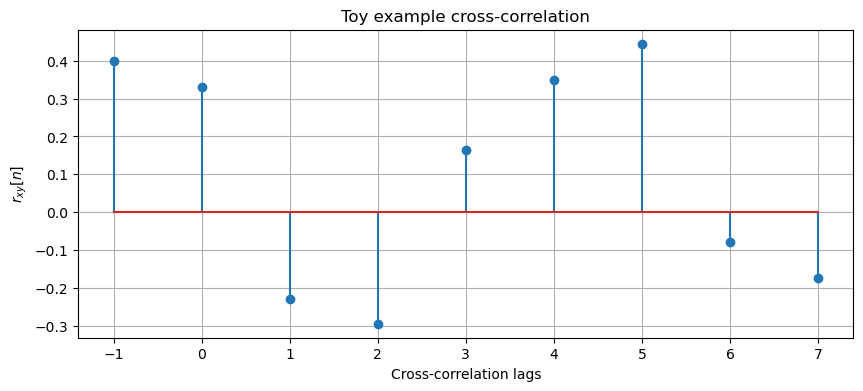

In [14]:
# Σήμα με θόρυβο
x = np.asarray([1, 0.2, -0.7, -0.3, 0.6, 0.5, 0.8, -0.7])

# Σήμα θορύβου
y = np.asarray([0.25, 0.4])

# Ετεροσυσχέτιση
cc = signal.correlate(x, y, 'full')

# Καθυστερήσεις 
lags = signal.correlation_lags(len(x), len(y), mode="full")

# Γράφημα
fig = plt.figure(figsize=(10,4))
plt.grid()
plt.stem(lags, cc)
plt.xlabel('Cross-correlation lags')
plt.ylabel('$r_{xy}[n]$')
plt.title('Toy example cross-correlation')
plt.show()

Τι παρατηρείτε για το μέγιστο της αυτοσυσχέτισης και τη χρονική στιγμή (lag) που βρίσκεται ($n=5$), σε σχέση με τη θέση του προτύπου σήματος θορύβου $y[n]$ μέσα στο "μολυσμένο" σήμα $x[n]$? (το τελευταίο μπορείτε να το βρείτε με το "μάτι", ψάχνοντας για τη δυάδα $(0.25, 0.4)$ ή κάποιο πολλαπλάσιό της μέσα στο σήμα $x[n]$).

----

Επιστρέφοντας στο αρχικό πρόβλημα, ο παρακάτω κώδικας θα σας βοηθήσει. Χρησιμοποιήστε το *documentation* όπου έχετε αμφιβολία.

Η συνάρτηση ```find_peaks``` της βιβλιοθήκης ```SciPy``` είναι πολύ βολική για να βρίσκετε κορυφές σε μια συνάρτηση, ανάλογα με το πόσο απέχουν μεταξύ τους, με το αν θέλετε να υπερβαίνουν κάποια τιμή, κλπ. Ρίξτε απλά μια ματιά στο *documentation* της συνάρτησης για να δείτε τις δυνατότητές της, μια και η εντολή όπως δίνεται στον παραπάνω κώδικα είναι πλήρης. Ελέγξτε προσεκτικά τις θέσεις των καθυστερήσεων (τις τιμές των ``locs`` δηλαδή) που σας επιστρέφει η ```find_peaks```. Δείτε τι υπάρχει στο θορυβώδες σήμα σε αυτές τις χρονικές στιγμές. 

## Απάντηση:

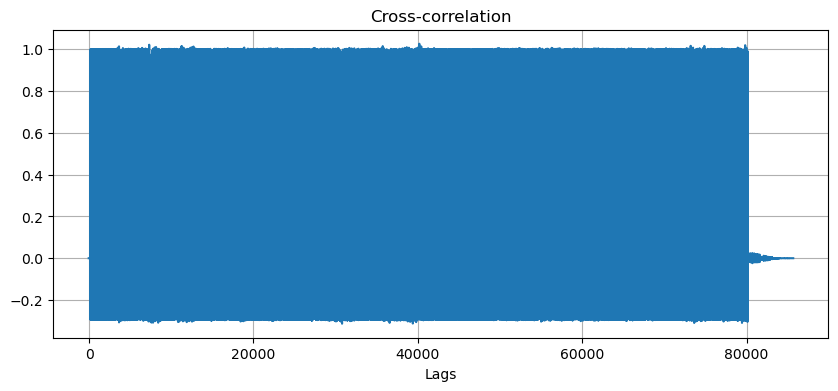

In [13]:
cross_corr = np.correlate(noisy, pattern, 'full')  # Υπολογίστε την ετεροσυσχέτιση
lags = signal.correlation_lags(len(noisy), len(pattern), mode="full")  # Υπολογίστε τον άξονα των lags [l]

fig = plt.figure(figsize=(10,4)) 
plt.plot(lags, cross_corr); # Δείτε προσεκτικά το σχήμα
plt.xlabel('Lags')
plt.title('Cross-correlation')
plt.grid()
plt.show()

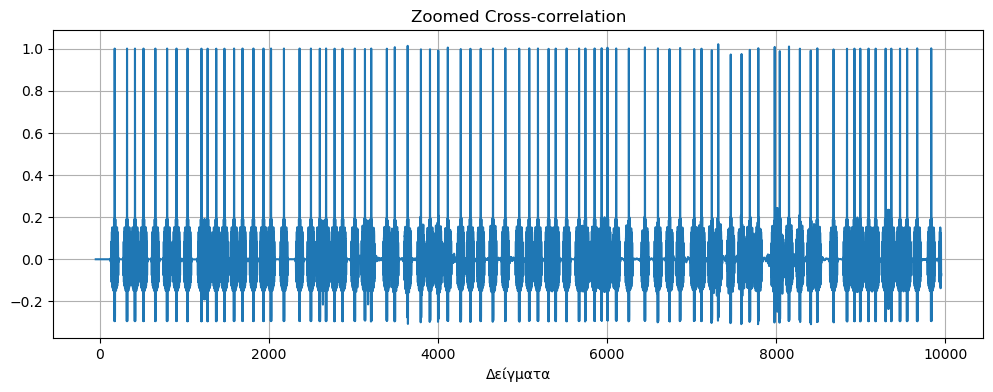

In [12]:
# Χρησιμοποιώντας το σχήμα, επιλέξτε ένα κατώφλι Τ
# που διαχωρίζει τα peaks απ'το υπόλοιπο, μη ωφέλιμο, σήμα
# Ας ζουμάρουμε!
fig = plt.figure(figsize=(12,4)) 
plt.plot(lags[0:10000], cross_corr[0:10000]) # Δείτε προσεκτικά το σχήμα
plt.xlabel('Lags')
plt.title('Zoomed Cross-correlation') 
plt.xlabel('Δείγματα')
plt.grid()
plt.show()

In [9]:
T = 0.4           # Ποιό είναι το κατώφλι που επιλέξατε?

# Χρησιμοποιήστε την signal.findpeaks για να ανιχνεύσετε τα σημεία υηψλής συσχέτισης
# Tο κατώφλι Τ θα χρησιμοποιηθεί ως το ελάχιστο ύψος peak που θέλετε να πάρετε
#-------------------------------------------------------------

[locs, pks] = signal.find_peaks(cross_corr, T)    # Χρήση της signal.findpeaks
locs = lags[locs]
pks = np.array(list(pks.values())).ravel()

# ------------------------------------------------------------
# Ελέγξτε το αποτέλεσμά σας χωρίς να μετρήσετε χειροκίνητα :)
print(f'Peaks detected = {locs.size}') # είναι 650 ?????

Peaks detected = 650


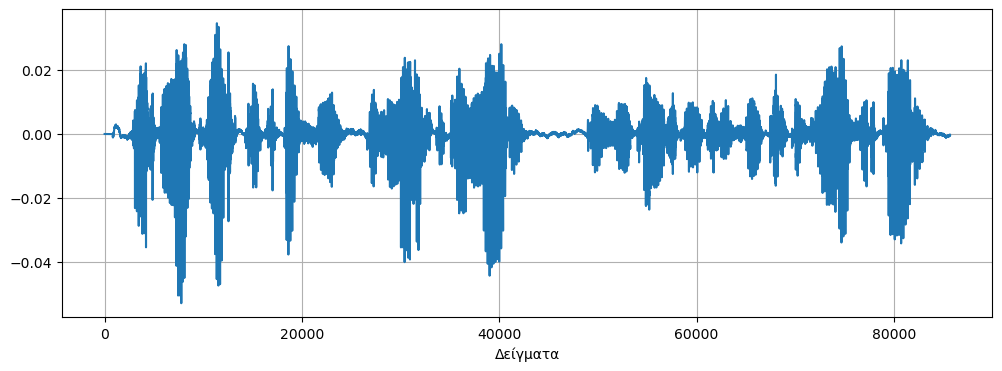

In [10]:
# Αντιγράψτε το σήμα με θόρυβο για να το επεξεργαστείτε
clean = np.copy(noisy)

# Αφαιρέστε το πρότυπο σήμα θορύβο από το σήμα με θόρυβο - χρησιμοποιήστε το διάνυσμα "clean" 
# Για κάθε δείκτη στο διάνυσμα lag που έχετε στο διάνυσμα locs, πρέπει να αφαιρέσετε το σήμα προτύπου
# από το σήμα με θόρυβο
# Χρησιμοποιήστε τον τελεστή ":" για να επιλέξετε τμήματα του σήματος ως εξής:
# clean[start:end] = clean[start:end] - noise[start:end];
for i in range(0, len(locs), 1):
    clean[locs[i]:locs[i] + len(pattern)] = noisy[locs[i]:locs[i] + len(pattern)] - pattern

# Για δείτε!
fig = plt.figure(figsize=(12,4))
plt.plot(clean)
plt.xlabel('Δείγματα')
plt.grid()
plt.show()

In [11]:
# Ακούστε! Πρέπει να είναι πεντακάθαρο...
Audio(clean, rate=fs)             # ακούμε! :)

---
---